# Simulating iceberg "Juliette"

In [1]:
#Imports
import pandas as pd
import xarray as xr
import numpy as np
from opendrift.models.openberg import OpenBerg
from opendrift.readers.reader_netCDF_CF_generic import Reader    
from datetime import datetime,timedelta, timezone

In [2]:
#Define additional functions
def calc_iceberg_size(iceberg_in1):
    '''Correct iceberg size not supplied with empirical relations before seeding iceberg.
    '''
    lengths = np.array(iceberg_in1['length'])
    if 'length' in iceberg_in1 and 'width' not in iceberg_in1:
        iceberg_in1['width'] = 0.7*lengths*np.exp(-0.00062*lengths)
    if 'length' in iceberg_in1 and np.logical_or('draft' not in iceberg_in1,'sail' not in iceberg_in1):
        rho_i, rho_w = 900,1027 #kg/m3
        height = np.array(0.4*lengths*np.exp(-0.00062*lengths))
        if np.logical_and('draft' not in iceberg_in1, 'sail' in iceberg_in1): print('Implement')
        elif np.logical_and('draft' not in iceberg_in1, 'sail' not in iceberg_in1): draft = height*(rho_i/rho_w)
        if np.logical_and('sail' not in iceberg_in1, 'draft' not in iceberg_in1): sail = height*(1-rho_i/rho_w) 
        elif np.logical_and('sail' not in iceberg_in1, 'draft' in iceberg_in1): print('Implement')
        iceberg_in1['draft'] = draft
        iceberg_in1['sail'] = sail
    return iceberg_in1

In [3]:
#Read and subset tracker data
df = pd.read_csv('../input/Osker-X2.csv', sep=';')
df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
ds = xr.Dataset.from_dataframe(df)
ds_daily = ds.groupby("time.date").first() #Daily subset
ds_3day = ds_daily.isel(date=slice(0, None, 3)) #3-daily subset

In [5]:
#Dictionary of available input data
env={#ocean
    'topaz4': 'cmems_mod_arc_phy_my_topaz4_P1D-m',
#     'topaz4_ensemble':'https://thredds.met.no/thredds/dodsC/accibergt42/topaz4_be_mem010.ncml',#find under:'https://thredds.met.no/thredds/catalog/accibergt42/catalog.html',
    'topaz5': 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m',
#    'topaz5_ensemble': '', #find under: https://thredds.met.no/thredds/catalog/accibergt5/catalog.html',
#    'topaz6': '',
    'glophyanfc': 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m', #Global anfc (mercator)
    'glorys': 'cmems_mod_glo_phy_my_0.083deg_P1D-m',
    #sea ice
    'nextsimanfc':'cmems_mod_arc_phy_anfc_nextsim_hm',
    'nextsimre':'cmems_mod_arc_phy_my_nextsim_P1D-m',
    #wave, add more
    'arcmfcwam':'dataset-wam-arctic-1hr3km-be',
    'arcmfcwamre':'cmems_mod_arc_wav_my_3km_PT1H-i',
    'mfwam':'cmems_mod_glo_wav_anfc_0.083deg_PT3H-i',
    'waverys':'cmems_mod_glo_wav_my_0.2deg_PT3H-i',
    #wind
    'wind_glophyre':'cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H', #availability; 2007-2026
    'wind_glophynrt':'cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H', #availability: 2024-2026
    'era5':'../input/era5_juliette.nc'} #Has to be downloaded

In [6]:
#Define index of initial simulation time steps
idx = np.arange(ds_3day.lat.size) #here, 3-dayly throughout observed trajectory, ADAPT!
print(idx)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 33.67it/s]
INFO - 2026-05-13T16:20:47Z - Selected dataset version: "202311"
INFO - 2026-05-13T16:20:47Z - Selected dataset part: "default"
Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 42.34it/s]
INFO - 2026-05-13T16:20:48Z - Selected dataset version: "202506"
INFO - 2026-05-13T16:20:48Z - Selected dataset part: "default"
Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00,  5.03it/s]
INFO - 2026-05-13T16:20:49Z - Selected dataset version: "202411"
INFO - 2026-05-13T16:20:49Z - Selected dataset part: "default"
Fetching catalogue 1: 100%|██████████| 2/2 [00:00<00:00, 42.98it/s]
INFO - 2026-05-13T16:20:50Z - Selected dataset version: "202207"
INFO - 2026-05-13T16:20:50Z - Selected dataset part: "default"


<xarray.Dataset> Size: 32MB
Dimensions:                                   (trajectory: 110, time: 1729)
Coordinates:
  * trajectory                                (trajectory) int32 440B 0 ... 109
  * time                                      (time) datetime64[ns] 14kB 2025...
Data variables: (12/39)
    status                                    (trajectory, time) float64 2MB ...
    moving                                    (trajectory, time) float64 2MB ...
    age_seconds                               (trajectory, time) float32 761kB ...
    origin_marker                             (trajectory, time) float64 2MB ...
    lon                                       (trajectory, time) float32 761kB ...
    lat                                       (trajectory, time) float32 761kB ...
    ...                                        ...
    sea_water_salinity                        (trajectory, time) float32 761kB ...
    sea_ice_area_fraction                     (trajectory, time) float32 761kB ...
    sea_ice_thickness                         (trajectory, time) float32 761kB ...
    sea_ice_x_velocity                        (trajectory, time) float32 761kB ...
    sea_ice_y_velocity                        (trajectory, time) float32 761kB ...
    land_binary_mask                          (trajectory, time) float32 761kB ...
Attributes: (12/147)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               nan
    geospatial_vertical_max:                                               nan
    geospatial_vertical_positive:                                          up

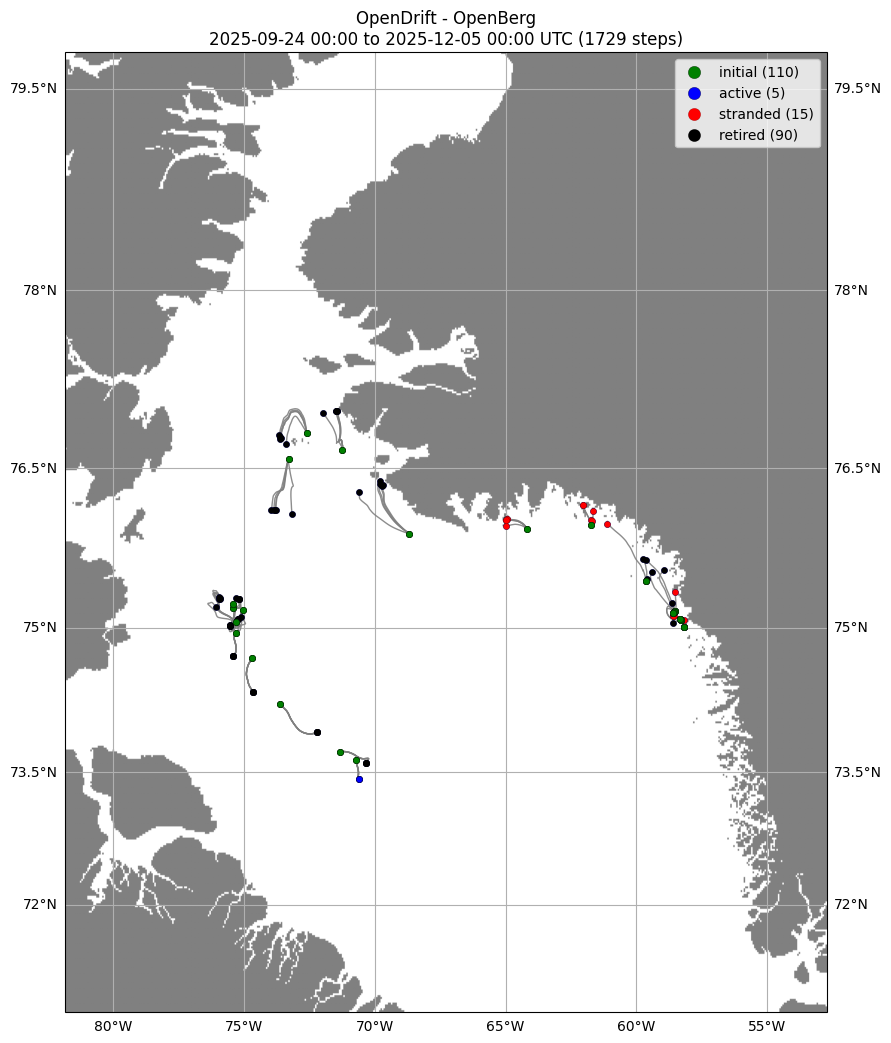

In [7]:
#definitions: ADAPT!
ib_duration = 3 #in days, How long every iceberg is simulated after its individual initialisation (iceberg age)
wind_in = ['wind_glophynrt',] #choose wind input
oc_in = ['topaz4',['nextsimanfc','topaz4','arcmfcwam'],] #choose ocean sea ice and wave input, if nested list of mulitple ocean/sea ice data order by priority!
lons, lats, times = ds_3day.lon[idx],ds_3day.lat[idx],[t.values.astype(datetime) for t in ds_3day.time[idx]] #input of lat, lon and time

#
input_l  = [(oc if isinstance(oc, list) else [oc]) + [wi] for wi in wind_in for oc in oc_in]
for envinput in input_l: #Loops through the ocean and wind input
        #----Information that are similar (or varied similarely) for every initialisation.----
        n=5 #number of icebergs released on every initialisation
        randspace=np.random.rand(n)
        #iceberg = {'length':150+randspace*100,'width':80+randspace*10, 
         #       'water_form_drag_coef':0.25+randspace*1.25,'wind_form_drag_coef':0.5+randspace*1} #Randomised sizes and coefficients
        iceberg = {'length':[50,2000,500,1000,2000], 
               'water_form_drag_coef':0.25+randspace*1.25,'wind_form_drag_coef':0.5+randspace*1} #hardcoded input size
        iceberg = calc_iceberg_size(iceberg) #this function adds missing iceberg sizes
        #---Simulation---
        o=OpenBerg(loglevel=20,logfile='../results/out.log')
        o.set_config('drift:max_age_seconds', ib_duration*3600*24) #Terminates simulations  ib_duration seconds after their individual initialisation
        #o.set_config('drift:vertical_profile',True)
        o.set_config('drift:stokes_drift',True)
        o.add_readers_from_list([env[envin] for envin in envinput]) 
        for lon, lat, time in zip(lons, lats, times): #Loops through initialisations of time-positions
            o.seed_elements(lon=lon, lat=lat, time=time, number=n, radius=0, **iceberg)
        oi = o.run(duration=timedelta(days=int(idx.size*ib_duration)), #duration from first initialisation to last termination not equal to ib age!
                   outfile='../results/juliette_%s.nc'%(envinput))
        o.plot(fast=True,filename='../results/juliette_map_%s.png'%(envinput))
oi

In [16]:
#Some checks
print('proportion of trajectories that became stranded (at any time)',np.mean(np.any(oi.status==1,axis=1)).values)
print('proportion of trajectories that are stranded (at the end of simulations)',np.mean(oi.status[:,-1]==1).values)
print('proportion of trajectories that meltet',np.mean(np.any(oi.status==2,axis=1)).values)
print('which size do melted trajectories have??',oi.sail[np.any(oi.status==2,axis=1),0].values)

proportion of trajectories that became stranded (at any time) 0.13636363636363635
proportion of trajectories that are stranded (at the end of simulations) 0.0
proportion of trajectories that meltet 0.0
which size do melted trajectories have?? []


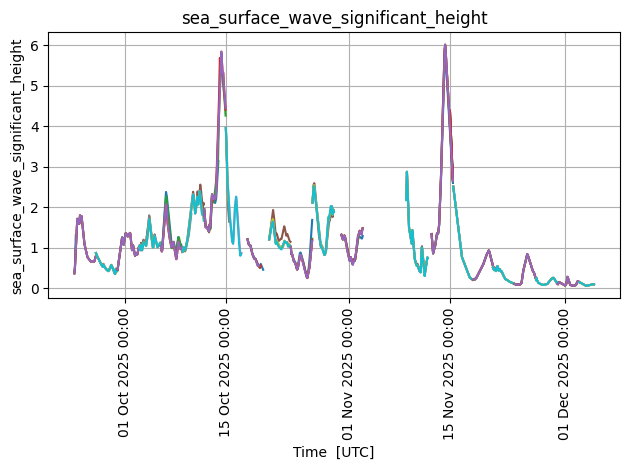

In [17]:
o.plot_property('sea_surface_wave_significant_height')#,filename='../results/juliette_property.png')
#other usedfull properties to plot: draft, sail, length, width, status, x_Wind